In [1]:
import tensorflow as tf

In [2]:
(x_train, y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
# reshaping the training and testing dataset
x_train=x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test=x_test.reshape(x_test.shape[0], 28, 28, 1)

In [6]:
# Neural networks work best with floating-point numbers rather than integers, so we are converting the type to float here
x_train = x_train.astype('float32')
x_test=x_test.astype('float32')

In [7]:
# normalize the pixel values to the range [0, 1] by dividing by 255:
x_train /= 255
x_test /= 255
input_shape=(28,28,1)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))
          
          

C:\Users\Inst_\anaconda3\envs\aiml1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x=x_train,y=y_train, epochs=10)
              

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9953 - loss: 0.0136
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9958 - loss: 0.0118
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9963 - loss: 0.0111
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9960 - loss: 0.0118
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9970 - loss: 0.0099
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9966 - loss: 0.0099
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9969 - loss: 0.0106
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9968 - loss: 0.0098
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9971 - loss: 0.0082
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9965 - loss: 0.0111


In [10]:
# evaluating model
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9805 - loss: 0.0736    


[0.05793827027082443, 0.9850000143051147]

In [11]:
# predicting the labels
y_predict=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


In [12]:
y_predict[0]

array([3.2817010e-11, 1.3191939e-12, 3.3606287e-10, 3.7124397e-07,
       1.6296946e-13, 1.8107190e-13, 2.1425413e-16, 9.9999964e-01,
       3.3998929e-10, 1.4762629e-09], dtype=float32)

In [14]:
import numpy as np
y_predicts=np.argmax(y_predict, axis=1)

In [17]:
y_test[0]

np.uint8(7)

In [15]:
y_predicts

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [18]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

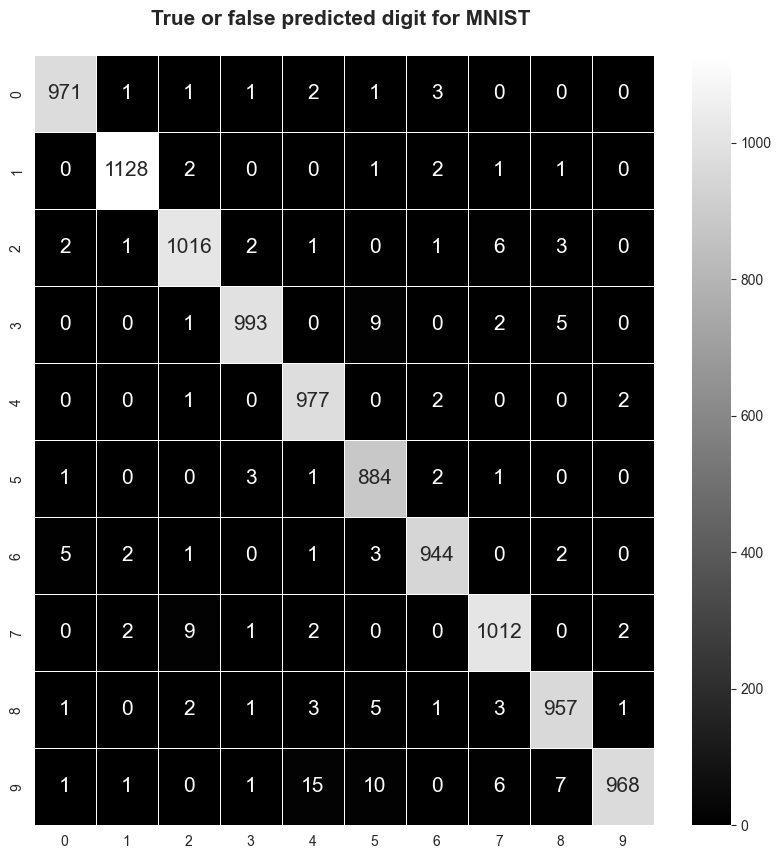

In [30]:
# confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
con_mat=confusion_matrix(y_test,y_predicts)
#visualizing confusion matrix
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('deep')
# mentioning number of rows and columns, here we  have 0 to 9 i.e ten digits so ten rows and ten columns to display confusion matrix for actual and 
# predicted values
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidth=0.5,fmt="d",cmap="gray")
plt.title("True or false predicted digit for MNIST \n", fontweight='bold',fontsize=15)
plt.show()

In [31]:
# Classification report
print(classification_report(y_test,y_predicts))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.98      0.99      0.98       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.99      0.96      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.99      0.98      0.98     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
9


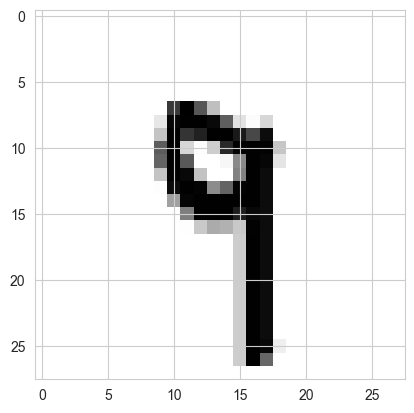

In [42]:
#Verifying the predicted image by passing a image index
image_index=6910
plt.imshow(x_test[image_index].reshape(28,28),cmap='Greys')
pred=model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(pred.argmax())